# Wildfire Detection  BINARY V1



## 1. Setup & Imports

In [10]:


%load_ext autoreload
%autoreload 2

import os
import re
import shutil
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from PIL import Image
import imagehash

import utils as ml_utils
import config as ml_config
import model as ml_model

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, regularizers
from tensorflow.keras.callbacks import (
    EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
)
from sklearn.metrics import (
    classification_report, confusion_matrix, ConfusionMatrixDisplay,
    roc_curve, auc
)

# Reproducibility
random.seed(ml_config.SEED)
np.random.seed(ml_config.SEED)
tf.random.set_seed(ml_config.SEED)


print("TensorFlow:", tf.__version__)


TensorFlow: 2.16.1


## 2. Dataset Exploration

In [3]:

train_counts = ml_utils.count_images(ml_config.TRAIN_DIR)
test_counts  = ml_utils.count_images(ml_config.TEST_DIR)

# Identify lake frames within No_Fire
train_nofire_files = list((ml_config.TRAIN_DIR / "No_Fire").glob("*.jpg"))
n_lake_train = sum(1 for f in train_nofire_files if f.name.startswith("lake"))
n_nofire_train = len(train_nofire_files) - n_lake_train

test_nofire_files  = list((ml_config.TEST_DIR / "No_Fire").glob("*.jpg"))
n_lake_test  = sum(1 for f in test_nofire_files if f.name.startswith("lake"))
n_nofire_test = len(test_nofire_files) - n_lake_test

summary = pd.DataFrame({
    "Split":    ["Train", "Train", "Train", "Test", "Test", "Test"],
    "Class":    ["Fire",  "No Fire (non-lake)", "No Fire (lake)",
                 "Fire",  "No Fire (non-lake)", "No Fire (lake)"],
    "Count":    [train_counts["Fire"], n_nofire_train, n_lake_train,
                 test_counts["Fire"],  n_nofire_test,  n_lake_test],
})
print(summary.to_string(index=False))
print(f"\nTotal train: {sum(train_counts.values()):,}  |  Total test: {sum(test_counts.values()):,}")


Split              Class  Count
Train               Fire  25018
Train No Fire (non-lake)   2510
Train     No Fire (lake)  11847
 Test               Fire   5137
 Test No Fire (non-lake)   3480
 Test     No Fire (lake)      0

Total train: 39,375  |  Total test: 8,617


In [4]:
fire_paths  = list((ml_config.TRAIN_DIR / "Fire").glob("*.jpg"))
nofire_paths = [f for f in train_nofire_files if not f.name.startswith("lake")]
lake_paths   = [f for f in train_nofire_files if f.name.startswith("lake")]

print(f"Fire: {len(fire_paths)}  |  No Fire (non-lake): {len(nofire_paths)}  |  No Fire (lake): {len(lake_paths)}")

Fire: 25018  |  No Fire (non-lake): 2510  |  No Fire (lake): 11847


## 3. Perceptual Deduplication


In [5]:

print("Deduplicating Fire frames …")
fire_sorted   = sorted(fire_paths,   key=ml_utils.frame_number)
fire_deduped  = ml_utils.deduplicate(fire_sorted)

print("Deduplicating No Fire (non-lake) frames …")
nofire_sorted  = sorted(nofire_paths,  key=ml_utils.frame_number)
nofire_deduped = ml_utils.deduplicate(nofire_sorted)

print("Deduplicating Lake frames …")
lake_sorted   = sorted(lake_paths,   key=ml_utils.frame_number)
lake_deduped  = ml_utils.deduplicate(lake_sorted)

print(f"\nFire:    {len(fire_paths):>6,}  →  {len(fire_deduped):>6,}  "
      f"({100*(1-len(fire_deduped)/len(fire_paths)):.1f}% removed)")
print(f"No Fire: {len(nofire_paths):>6,}  →  {len(nofire_deduped):>6,}  "
      f"({100*(1-len(nofire_deduped)/len(nofire_paths)):.1f}% removed)")
print(f"Lake:    {len(lake_paths):>6,}  →  {len(lake_deduped):>6,}  "
      f"({100*(1-len(lake_deduped)/len(lake_paths)):.1f}% removed)")


Deduplicating Fire frames …
Deduplicating No Fire (non-lake) frames …
Deduplicating Lake frames …

Fire:    25,018  →   1,913  (92.4% removed)
No Fire:  2,510  →     566  (77.5% removed)
Lake:    11,847  →     995  (91.6% removed)


## 4. Data Preparation




In [ ]:
AUTOTUNE = tf.data.AUTOTUNE

# building datasets for binary classification
bin_train_ds, bin_val_ds, bin_test_ds, bin_train_labels, bin_val_labels,bin_test_labels = (
    ml_utils.build_binary_datasets(fire_deduped, nofire_deduped, lake_deduped, lake_as_nofire=False)
)

# class weight to handle Fire >> No-Fire imbalance
n_fire   = bin_train_labels.count(1)
n_nofire = bin_train_labels.count(0)
total    = n_fire + n_nofire
binary_class_weights = {0: total / (2 * n_nofire),
                        1: total / (2 * n_fire)}
print("Binary class weights:", {k: f"{v:.3f}" for k, v in binary_class_weights.items()})
print(f"Binary train batches: {len(bin_train_ds)}  |  val: {len(bin_val_ds)}  |  test: {len(bin_test_ds)}")


Binary class weights: {0: '2.187', 1: '0.648'}
Binary train batches: 67  |  val: 12  |  test: 270


## Binary Model (V1)



In [13]:
binary_model = ml_model.binary_micro_cnn()
binary_model.summary()


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 254, 254, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 127, 127, 8)    │           216 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 127, 127, 8)    │            32 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 127, 127, 8)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ depthwise_conv2d                │ (None, 127, 127, 8)    │            72 │
│ (DepthwiseConv2D)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 127, 127, 8)    │            32 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 127, 127, 8)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 127, 127, 16)   │           128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 127, 127, 16)   │            64 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_2 (Activation)       │ (None, 127, 127, 16)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ average_pooling2d               │ (None, 63, 63, 16)     │             0 │
│ (AveragePooling2D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 63, 63, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ depthwise_conv2d_1              │ (None, 63, 63, 16)     │           144 │
│ (DepthwiseConv2D)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 63, 63, 16)     │            64 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_3 (Activation)       │ (None, 63, 63, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 63, 63, 32)     │           512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 63, 63, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_4 (Activation)       │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ average_pooling2d_1             │ (None, 31, 31, 32)     │             0 │
│ (AveragePooling2D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 31, 31, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼─────────────

 Total params: 11,569 (45.19 KB)

 Trainable params: 10,897 (42.57 KB)

 Non-trainable params: 672 (2.62 KB)

In [14]:
history_binary= binary_model.fit(
    bin_train_ds,
    validation_data=bin_val_ds,
    epochs=ml_config.EPOCHS,
    class_weight=binary_class_weights,
    callbacks=ml_config.binary_callbacks,
    verbose=1,
)

Epoch 1/100
67/67 ━━━━━━━━━━━━━━━━━━━━ 15s 180ms/step - accuracy: 0.6105 - auc: 0.6697 - loss: 0.1820 - precision: 0.8482 - recall: 0.6030 - val_accuracy: 0.2266 - val_auc: 0.5000 - val_loss: 0.1802 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00 - learning_rate: 0.0010
Epoch 2/100
67/67 ━━━━━━━━━━━━━━━━━━━━ 11s 169ms/step - accuracy: 0.7342 - auc: 0.7905 - loss: 0.1510 - precision: 0.8949 - recall: 0.7427 - val_accuracy: 0.2266 - val_auc: 0.4948 - val_loss: 0.2508 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00 - learning_rate: 0.0010
Epoch 3/100
67/67 ━━━━━━━━━━━━━━━━━━━━ 12s 178ms/step - accuracy: 0.8001 - auc: 0.8774 - loss: 0.1162 - precision: 0.9293 - recall: 0.8018 - val_accuracy: 0.2266 - val_auc: 0.5115 - val_loss: 0.3970 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00 - learning_rate: 0.0010
Epoch 4/100
67/67 ━━━━━━━━━━━━━━━━━━━━ 0s 161ms/step - accuracy: 0.8239 - auc: 0.9124 - loss: 0.0992 - precision: 0.9419 - recall: 0.8203
Epoch 4: ReduceLROnPlateau reducin

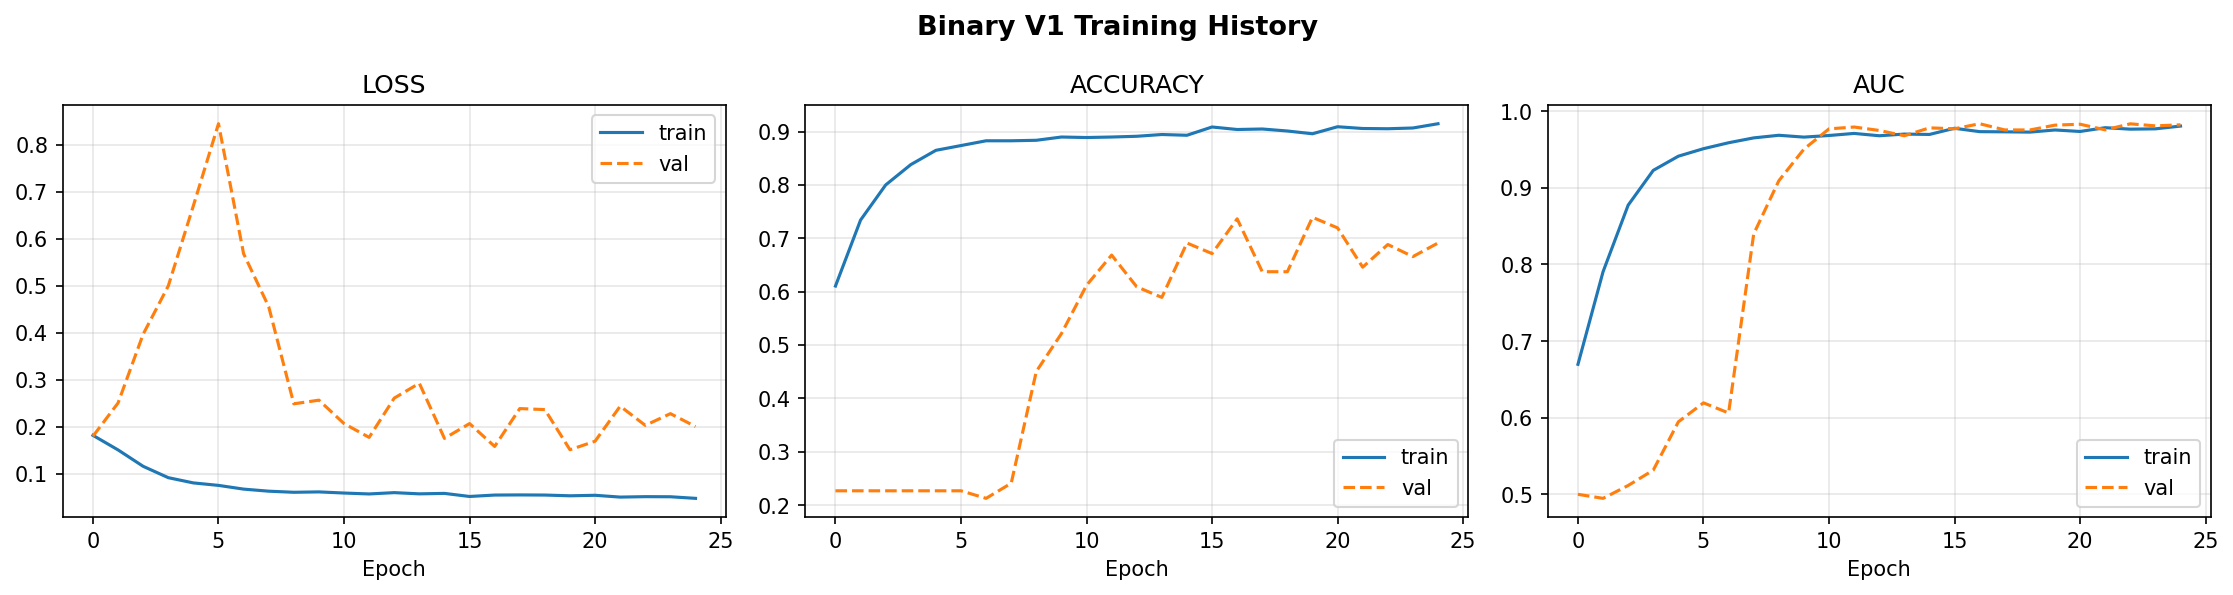

In [20]:
ml_utils.plot_history(history_binary,    "Binary V1 Training History")

## Evaluating model


  Binary Model V1 (Test)
              precision    recall  f1-score   support

     No Fire       0.51      0.96      0.67      3480
        Fire       0.94      0.38      0.55      5137

    accuracy                           0.62      8617
   macro avg       0.73      0.67      0.61      8617
weighted avg       0.77      0.62      0.60      8617

AUC: 0.8220


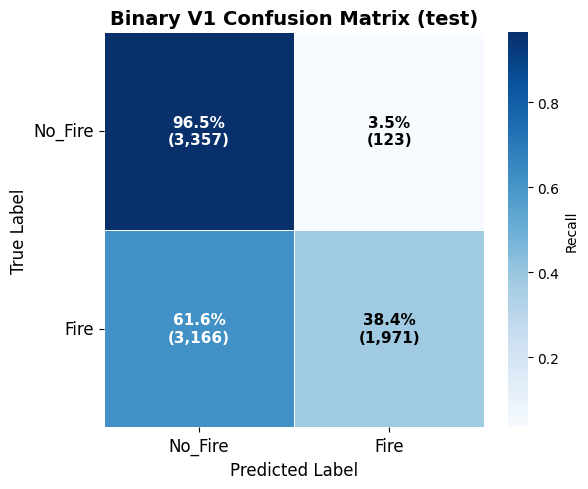

In [41]:

results_binary = []

results_binary.append(ml_utils.evaluate_binary(
    binary_model, bin_test_ds, bin_test_labels, "Binary Model V1 (Test)"))

ml_utils.plot_confusion_matrix(results_binary[0][0],results_binary[0][1],['No_Fire','Fire'], title="Binary V1 Confusion Matrix (test)")


  Binary Model V1 (Val)
              precision    recall  f1-score   support

     No Fire       0.46      1.00      0.63        80
        Fire       1.00      0.66      0.79       273

    accuracy                           0.74       353
   macro avg       0.73      0.83      0.71       353
weighted avg       0.88      0.74      0.76       353

AUC: 0.9837


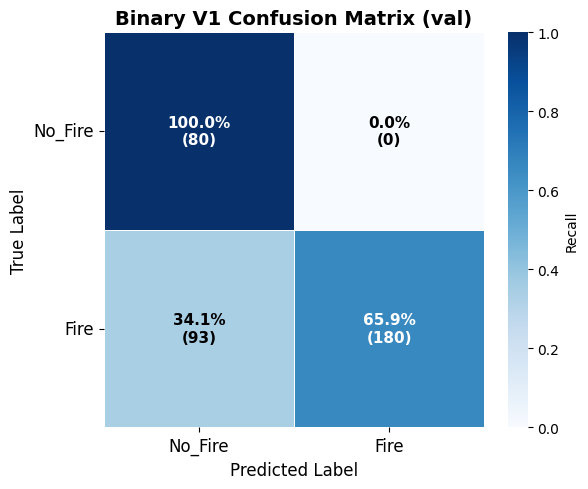

In [42]:
val_eval= ml_utils.evaluate_binary(
    binary_model, bin_val_ds, bin_val_labels, "Binary Model V1 (Val)")

ml_utils.plot_confusion_matrix(val_eval[0],val_eval[1],['No_Fire','Fire'], title="Binary V1 Confusion Matrix (val)")